Libraries loaded successfully
Test set  : (384, 21)
y_test    : mean=0.3353, std=0.8825
y_pred    : mean=0.3181, std=0.7002
=== Part A: Model Performance Bootstrap CI ===
  RMSE : 0.5596  95% CI [0.4253, 0.6886]
  MAE  : 0.2515  95% CI [0.2025, 0.3038]
  R2   : 0.5968  95% CI [0.3851, 0.7397]

=== Part B: Policy Simulation Bootstrap CI ===
  A-20 (Debt -20%)      : 0.0781  95% CI [0.0398, 0.1255]
  A-40 (Debt -40%)      : 0.1749  95% CI [0.1096, 0.2555]
  A-60 (Debt -60%)      : 0.2879  95% CI [0.1906, 0.3861]
  B-20 (Income +20%)    : 0.3502  95% CI [0.2181, 0.4953]
  B-40 (Income +40%)    : 0.5126  95% CI [0.3072, 0.7445]
  B-60 (Income +60%)    : 0.6381  95% CI [0.4013, 0.8665]
  C (A-40+B-40)         : 0.6331  95% CI [0.4029, 0.8653]

=== Part C: Subgroup Heterogeneity CI (Policy C) ===
  Employed    : n=15  DSR reduction=0.0114  95% CI [-0.0373, 0.0687]
  Unemployed  : n=13  DSR reduction=0.1620  95% CI [0.0775, 0.2599]
  Inactive    : n=2 (too small for CI)


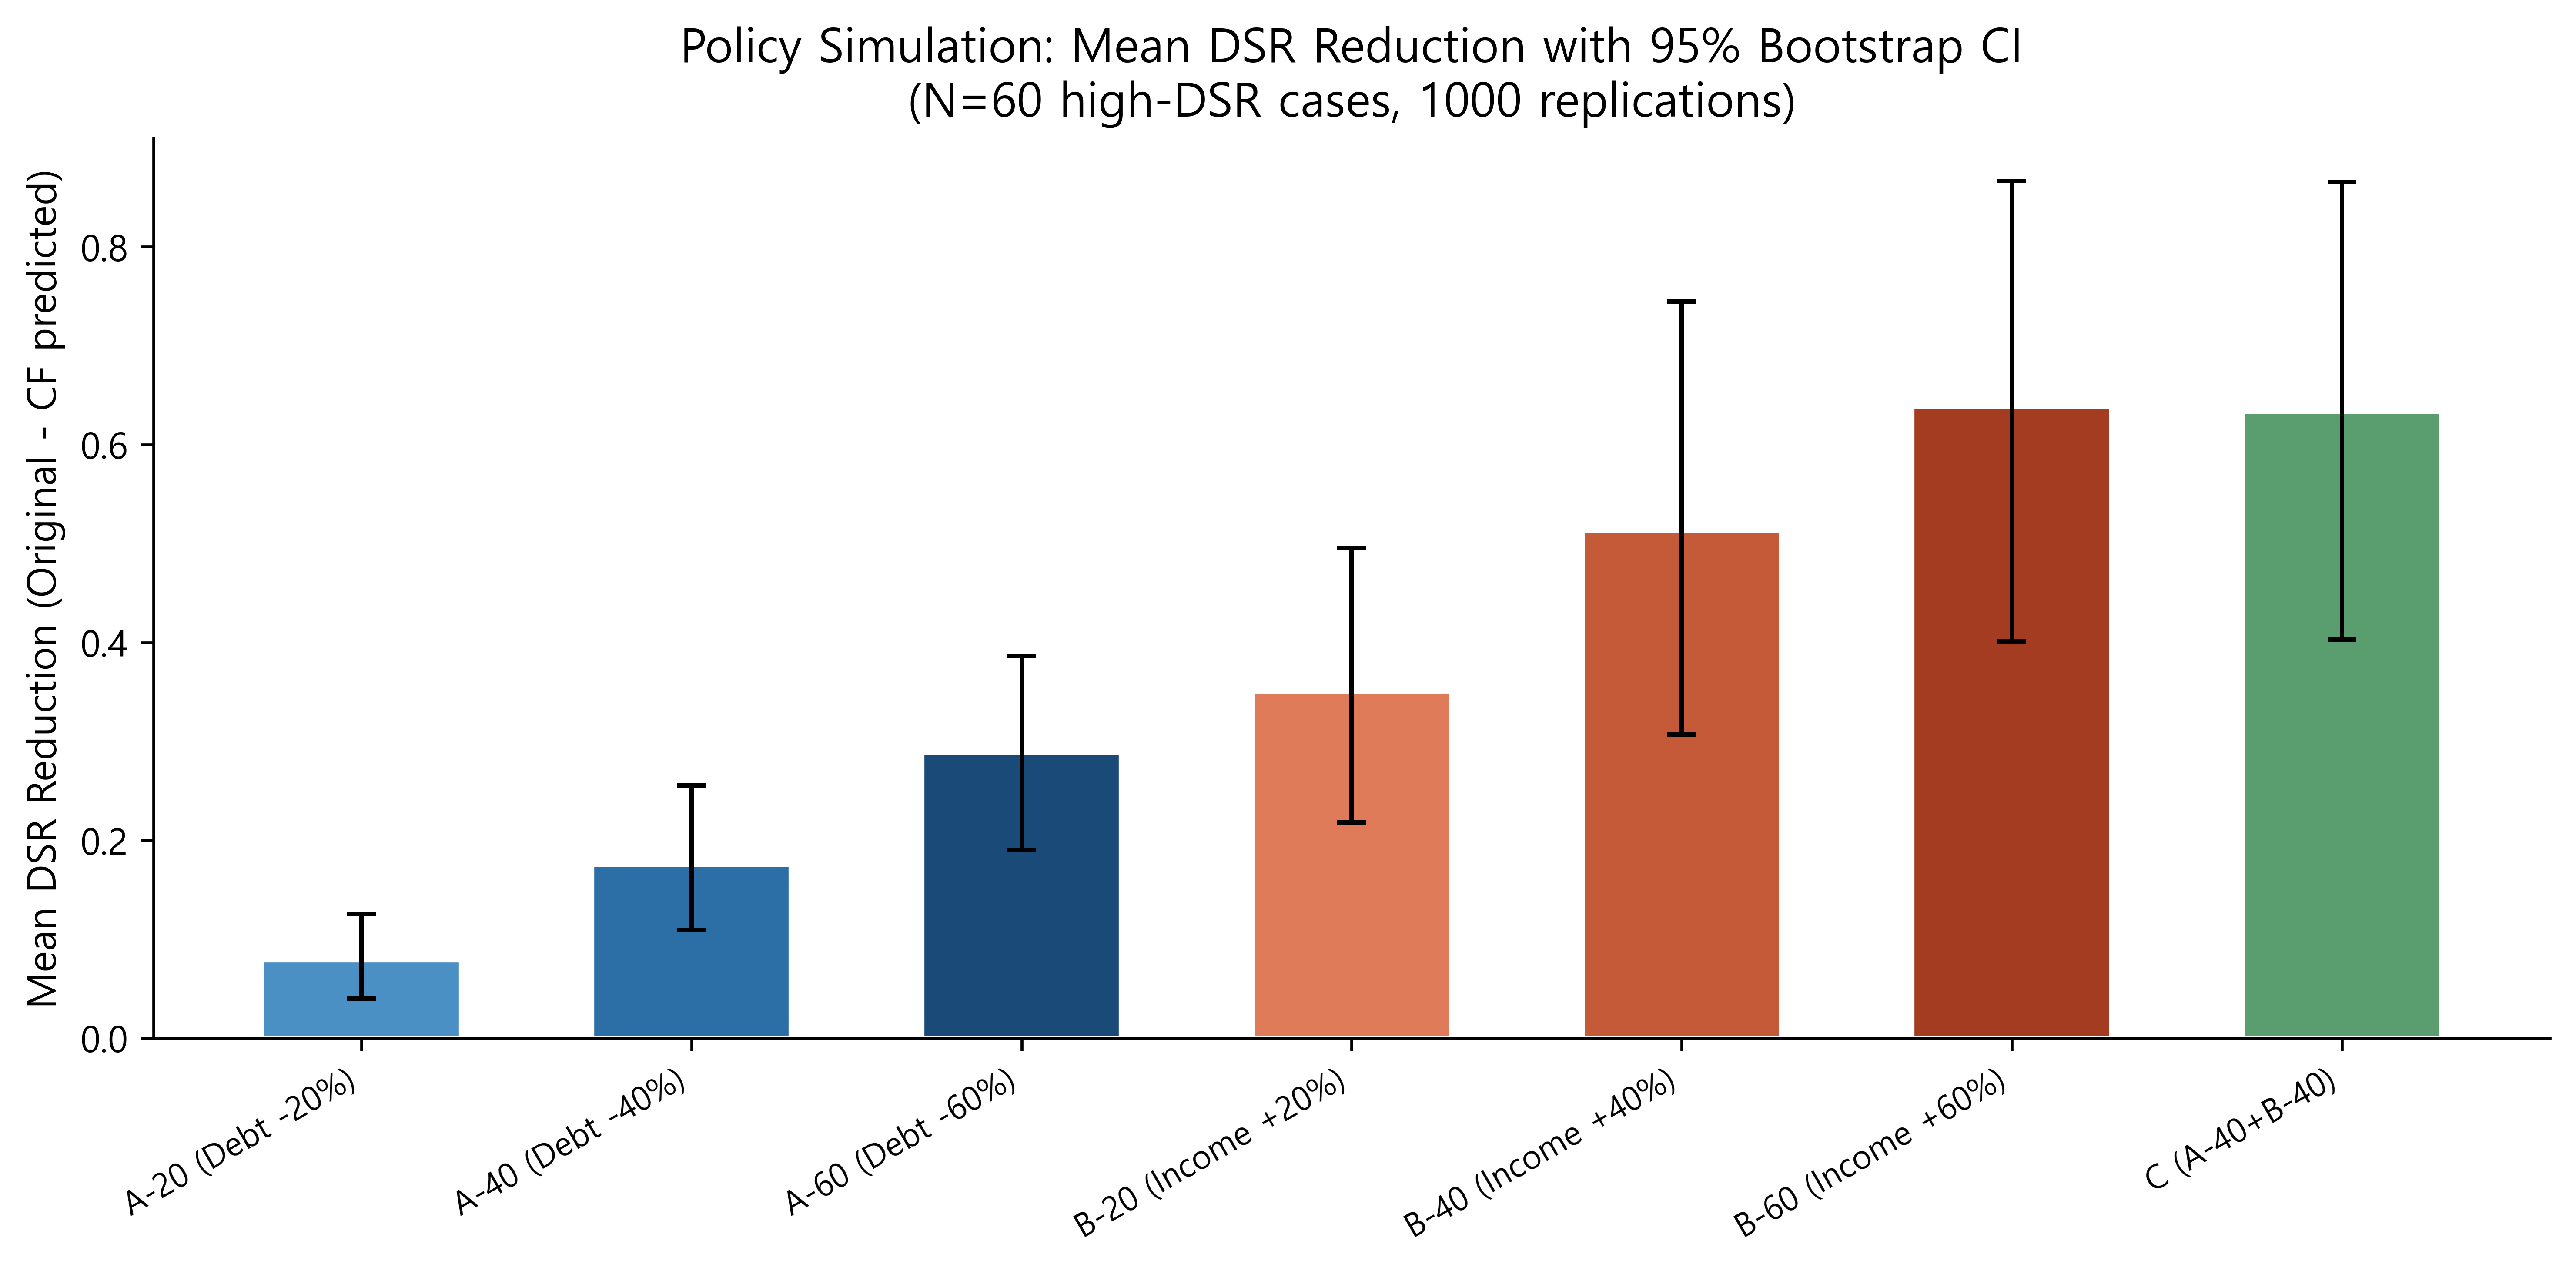

Saved -> outputs/30_policy_ci_reg.png


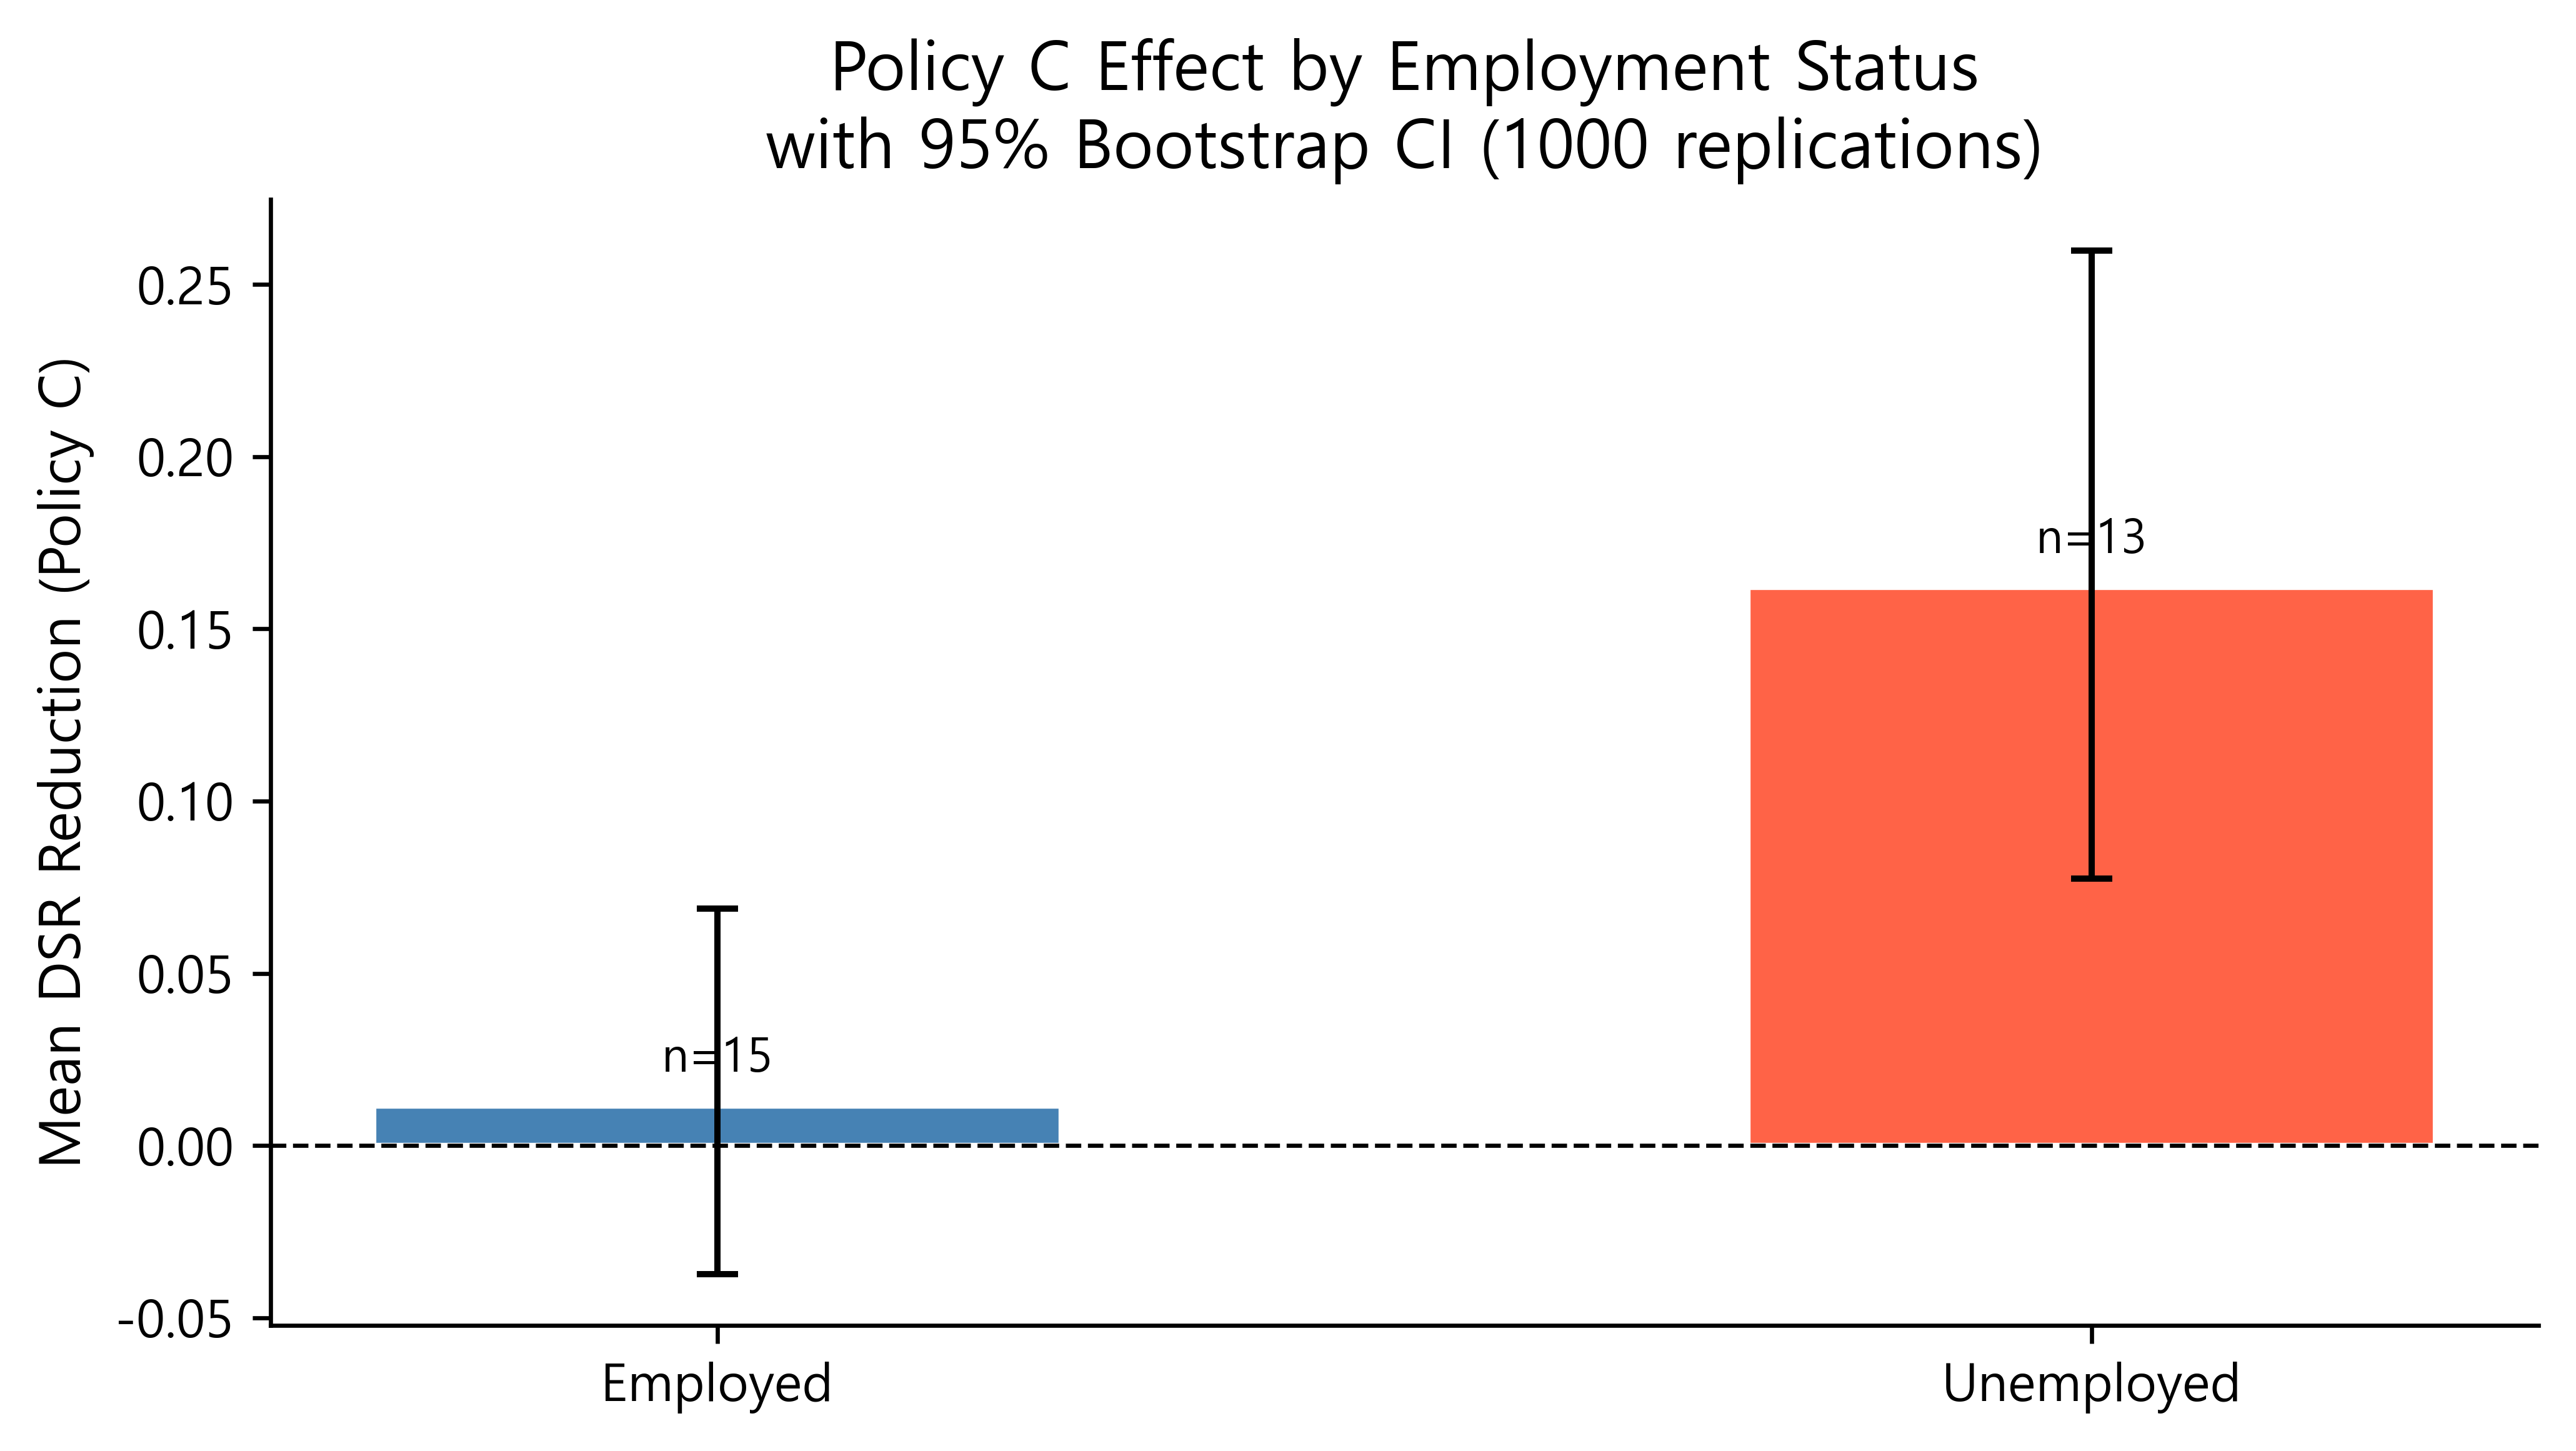

Saved -> outputs/31_subgroup_ci_reg.png
Saved -> outputs/bootstrap_ci_model_reg.csv
Saved -> outputs/bootstrap_ci_policy_reg.csv
Saved -> outputs/bootstrap_ci_subgroup_reg.csv

=== Final Summary ===
Metric  Point estimate  CI lower (95%)  CI upper (95%)
  RMSE          0.5596          0.4253          0.6886
   MAE          0.2515          0.2025          0.3038
    R2          0.5968          0.3851          0.7397

            Policy  Mean DSR reduction  CI lower (95%)  CI upper (95%)
  A-20 (Debt -20%)              0.0781          0.0398          0.1255
  A-40 (Debt -40%)              0.1749          0.1096          0.2555
  A-60 (Debt -60%)              0.2879          0.1906          0.3861
B-20 (Income +20%)              0.3502          0.2181          0.4953
B-40 (Income +40%)              0.5126          0.3072          0.7445
B-60 (Income +60%)              0.6381          0.4013          0.8665
     C (A-40+B-40)              0.6331          0.4029          0.8653

  Subgroup 

In [1]:
# ═══════════════════════════════════════════════════════════════
# Notebook  : 08_bootstrap_ci_regression
# Project   : XAI-Driven DSR Prediction Framework for Youth Debt Crisis
# Purpose   : Bootstrapped 95% confidence intervals for
#             (A) model performance metrics (RMSE, MAE, R2)
#             (B) policy simulation DSR reduction estimates
#             (C) subgroup heterogeneity estimates (employment status)
#             1,000 bootstrap replications; model held fixed
# Data      : X_test_reg.csv, y_test_reg.csv, model_lgbm_reg.pkl
# Author    :
# ═══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import joblib
from scipy.stats import bootstrap as scipy_bootstrap

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW   = dict(dpi=600, bbox_inches='tight', format='png')
N_BOOT    = 1000
RNG       = np.random.default_rng(42)
CI_LEVEL  = 0.95
DSR_THR   = 0.4   # regulatory threshold

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load model & data
# ─────────────────────────────────────────────
lgbm   = joblib.load('../outputs/model_lgbm_reg.pkl')
X_test = pd.read_csv('../data/X_test_reg.csv')
y_test = pd.read_csv('../data/y_test_reg.csv').squeeze()

X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)

y_pred   = lgbm.predict(X_test_r.values)

print(f"Test set  : {X_test_r.shape}")
print(f"y_test    : mean={y_test_r.mean():.4f}, std={y_test_r.std():.4f}")
print(f"y_pred    : mean={y_pred.mean():.4f}, std={y_pred.std():.4f}")


# ─────────────────────────────────────────────
# Cell 3 | Helper: bootstrap CI function
# Resamples test-set indices; model held fixed
# ─────────────────────────────────────────────
def bootstrap_ci(stat_fn, n_boot=N_BOOT, rng=RNG, ci=CI_LEVEL):
    """
    stat_fn: callable(idx) -> scalar statistic
    Returns (point_estimate, lower_ci, upper_ci)
    """
    n    = len(y_test_r)
    boot = np.array([stat_fn(rng.integers(0, n, size=n))
                     for _ in range(n_boot)])
    lo   = np.percentile(boot, (1 - ci) / 2 * 100)
    hi   = np.percentile(boot, (1 + ci) / 2 * 100)
    return boot, lo, hi


# ─────────────────────────────────────────────
# Cell 4 | Part A: Model performance CI
# RMSE, MAE, R2 on test set with 95% CI
# ─────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def rmse_fn(idx):
    return np.sqrt(mean_squared_error(y_test_r.iloc[idx],
                                      y_pred[idx]))

def mae_fn(idx):
    return mean_absolute_error(y_test_r.iloc[idx], y_pred[idx])

def r2_fn(idx):
    return r2_score(y_test_r.iloc[idx], y_pred[idx])

print("=== Part A: Model Performance Bootstrap CI ===")
partA_rows = []

for name, fn, point in [
    ('RMSE', rmse_fn, np.sqrt(mean_squared_error(y_test_r, y_pred))),
    ('MAE',  mae_fn,  mean_absolute_error(y_test_r, y_pred)),
    ('R2',   r2_fn,   r2_score(y_test_r, y_pred)),
]:
    boot, lo, hi = bootstrap_ci(fn)
    print(f"  {name:<5}: {point:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")
    partA_rows.append({
        'Metric'       : name,
        'Point estimate': round(point, 4),
        'CI lower (95%)': round(lo, 4),
        'CI upper (95%)': round(hi, 4),
    })

partA_df = pd.DataFrame(partA_rows)


# ─────────────────────────────────────────────
# Cell 5 | Part B: Policy simulation CI
# Bootstrap CI for mean DSR reduction under each policy
# ─────────────────────────────────────────────
# Restrict to high-DSR cases in test set
crisis_mask = y_test_r >= DSR_THR
X_crisis    = X_test_r[crisis_mask].reset_index(drop=True)
y_crisis    = y_test_r[crisis_mask].reset_index(drop=True)
pred_crisis = lgbm.predict(X_crisis.values)

POLICIES = {
    'A-20 (Debt -20%)' : {'debt_financial'  : -0.20},
    'A-40 (Debt -40%)' : {'debt_financial'  : -0.40},
    'A-60 (Debt -60%)' : {'debt_financial'  : -0.60},
    'B-20 (Income +20%)': {'h19_pers_income2': +0.20},
    'B-40 (Income +40%)': {'h19_pers_income2': +0.40},
    'B-60 (Income +60%)': {'h19_pers_income2': +0.60},
    'C (A-40+B-40)'    : {'debt_financial'  : -0.40,
                           'h19_pers_income2': +0.40},
}

def get_sim_preds(changes):
    X_sim = X_crisis.copy()
    for feat, delta in changes.items():
        if feat not in X_sim.columns:
            continue
        if delta < 0:
            X_sim[feat] = (X_sim[feat] * (1 + delta)).clip(lower=0)
        else:
            col_mean    = X_crisis[feat].mean()
            X_sim[feat] = X_sim[feat] + col_mean * delta
    return lgbm.predict(X_sim.values)

print("\n=== Part B: Policy Simulation Bootstrap CI ===")
partB_rows = []
n_crisis   = len(X_crisis)
rng_b      = np.random.default_rng(42)

for policy_name, changes in POLICIES.items():
    sim_preds = get_sim_preds(changes)
    dsr_red   = pred_crisis - sim_preds   # per-case reduction

    # Bootstrap: resample crisis cases
    boot_means = np.array([
        dsr_red[rng_b.integers(0, n_crisis, size=n_crisis)].mean()
        for _ in range(N_BOOT)
    ])
    point = dsr_red.mean()
    lo    = np.percentile(boot_means, 2.5)
    hi    = np.percentile(boot_means, 97.5)

    print(f"  {policy_name:<22}: {point:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")
    partB_rows.append({
        'Policy'              : policy_name,
        'Mean DSR reduction'  : round(point, 4),
        'CI lower (95%)'      : round(lo, 4),
        'CI upper (95%)'      : round(hi, 4),
    })

partB_df = pd.DataFrame(partB_rows)


# ─────────────────────────────────────────────
# Cell 6 | Part C: Subgroup heterogeneity CI
# Policy C effect by employment status with 95% CI
# ─────────────────────────────────────────────
emp_labels  = {1: 'Employed', 2: 'Unemployed', 3: 'Inactive'}
policy_key  = 'C (A-40+B-40)'
sim_preds_c = get_sim_preds(POLICIES['C (A-40+B-40)'])
dsr_red_c   = pred_crisis - sim_preds_c

print("\n=== Part C: Subgroup Heterogeneity CI (Policy C) ===")
partC_rows = []
rng_c      = np.random.default_rng(42)

for emp_val, emp_label in emp_labels.items():
    mask = (X_crisis['employment_status'] == emp_val).values
    if mask.sum() == 0:
        continue

    sub_red = dsr_red_c[mask]
    n_sub   = len(sub_red)
    point   = sub_red.mean()

    if n_sub < 5:
        lo, hi = np.nan, np.nan
        print(f"  {emp_label:<12}: n={n_sub} (too small for CI)")
    else:
        boot_sub = np.array([
            sub_red[rng_c.integers(0, n_sub, size=n_sub)].mean()
            for _ in range(N_BOOT)
        ])
        lo = np.percentile(boot_sub, 2.5)
        hi = np.percentile(boot_sub, 97.5)
        print(f"  {emp_label:<12}: n={n_sub}  "
              f"DSR reduction={point:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")

    partC_rows.append({
        'Subgroup'           : emp_label,
        'N'                  : int(n_sub),
        'Mean DSR reduction' : round(point, 4),
        'CI lower (95%)'     : round(lo, 4) if not np.isnan(lo) else 'N/A',
        'CI upper (95%)'     : round(hi, 4) if not np.isnan(hi) else 'N/A',
    })

partC_df = pd.DataFrame(partC_rows)


# ─────────────────────────────────────────────
# Cell 7 | Visualize Part B: Policy CI bar chart
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x      = np.arange(len(partB_df))
points = partB_df['Mean DSR reduction'].values
lows   = partB_df['CI lower (95%)'].values
highs  = partB_df['CI upper (95%)'].values
yerr   = np.array([points - lows, highs - points])

colors = ['#4a90c4','#2c6ea6','#1a4a78',
          '#e07b5a','#c45a38','#a33c20','#5a9e6f']

bars = ax.bar(x, points, color=colors, edgecolor='white',
              width=0.6, zorder=2)
ax.errorbar(x, points, yerr=yerr, fmt='none',
            color='black', capsize=4, capthick=1.2,
            elinewidth=1.2, zorder=3)
ax.axhline(0, color='black', lw=0.8, linestyle='--')

ax.set_xticks(x)
ax.set_xticklabels(partB_df['Policy'], rotation=30,
                   ha='right', fontsize=9)
ax.set_ylabel('Mean DSR Reduction (Original - CF predicted)')
ax.set_title('Policy Simulation: Mean DSR Reduction with 95% Bootstrap CI\n'
             f'(N={n_crisis} high-DSR cases, {N_BOOT} replications)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/30_policy_ci_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/30_policy_ci_reg.png")


# ─────────────────────────────────────────────
# Cell 8 | Visualize Part C: Subgroup CI bar chart
# ─────────────────────────────────────────────
partC_plot = partC_df[partC_df['CI lower (95%)'] != 'N/A'].copy()
partC_plot['CI lower (95%)'] = partC_plot['CI lower (95%)'].astype(float)
partC_plot['CI upper (95%)'] = partC_plot['CI upper (95%)'].astype(float)

if len(partC_plot) > 0:
    fig, ax = plt.subplots(figsize=(7, 4))

    x_sub  = np.arange(len(partC_plot))
    pts    = partC_plot['Mean DSR reduction'].values
    lows_s = partC_plot['CI lower (95%)'].values
    highs_s= partC_plot['CI upper (95%)'].values
    yerr_s = np.array([pts - lows_s, highs_s - pts])

    sub_colors = ['steelblue', 'tomato', 'seagreen'][:len(partC_plot)]
    bars = ax.bar(x_sub, pts, color=sub_colors,
                  edgecolor='white', width=0.5, zorder=2)
    ax.errorbar(x_sub, pts, yerr=yerr_s, fmt='none',
                color='black', capsize=4, capthick=1.2,
                elinewidth=1.2, zorder=3)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')

    for bar, row in zip(bars, partC_plot.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'n={row.N}', ha='center', fontsize=9)

    ax.set_xticks(x_sub)
    ax.set_xticklabels(partC_plot['Subgroup'])
    ax.set_ylabel('Mean DSR Reduction (Policy C)')
    ax.set_title('Policy C Effect by Employment Status\n'
                 f'with 95% Bootstrap CI ({N_BOOT} replications)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('../outputs/31_subgroup_ci_reg.png', **SAVE_KW)
    plt.show()
    print("Saved -> outputs/31_subgroup_ci_reg.png")


# ─────────────────────────────────────────────
# Cell 9 | Save all CI results
# ─────────────────────────────────────────────
partA_df.to_csv('../outputs/bootstrap_ci_model_reg.csv',
                index=False, encoding='utf-8-sig')
partB_df.to_csv('../outputs/bootstrap_ci_policy_reg.csv',
                index=False, encoding='utf-8-sig')
partC_df.to_csv('../outputs/bootstrap_ci_subgroup_reg.csv',
                index=False, encoding='utf-8-sig')

print("Saved -> outputs/bootstrap_ci_model_reg.csv")
print("Saved -> outputs/bootstrap_ci_policy_reg.csv")
print("Saved -> outputs/bootstrap_ci_subgroup_reg.csv")
print(f"\n=== Final Summary ===")
print(partA_df.to_string(index=False))
print()
print(partB_df.to_string(index=False))
print()
print(partC_df.to_string(index=False))